# 03 · MLP — V_in=30, V_out=90
### Taller B3-T4 — Redes Neuronales para Forecasting

Notebook individual para **una única combinación** del bucle 4×4. Forma parte de la familia de 16 notebooks `mlp_vin{V}_vout{V}.ipynb` en `03_mlp/`.

Patrón "1 notebook = 1 combo": se entrena el MLP sobre ventanas (V_in=30 → V_out=90) y se guarda **un único resultado parcial** y la curva de entrenamiento.

**Diseño de esta versión:** Narrower-but-deeper with heavy regularisation. The previous run collapsed train MAE to ~0.0015 while test was 27× higher — classic capacity overfit. This version uses 3 hidden layers of 96/48/48 with L2=2e-4 and dropout 0.45. Also fixes the EPOCHS=000 typo.

---

**Salidas generadas por este notebook**

| Carpeta | Fichero | Contenido |
|---|---|---|
| `08_results/tablas/parciales/` | `mlp_vin30_vout90.csv` | 1 fila: modelo, v_in, v_out, n_params, mae_train, mae_val, mae_test |
| `08_results/curvas/mlp/` | `mlp_vin30_vout90.png` | Curva loss/val_loss |

> ⚠️ La partición train/val/test usa `random_state=42` (cronológica) — **no modificar**.
> ⚠️ Para cambiar de combo: duplicar este notebook y modificar **solo** `V_IN, V_OUT` en la celda de constantes.

## 1. Entorno de ejecución

Detección automática Colab / local, montaje de Drive si procede, e inserción de `01_src_compartido` en `sys.path`.

In [1]:
import os, sys

def detect_env():
    try:
        import google.colab
        return 'colab'
    except ImportError:
        return 'local'

ENV = detect_env()

if ENV == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Taller4_DL_MIAX'
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))

SRC = os.path.join(BASE, '01_src_compartido')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

print(f'> Entorno : {ENV}')
print(f'> BASE    : {BASE}')
print(f'> SRC     : {SRC}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
> Entorno : colab
> BASE    : /content/drive/MyDrive/Taller4_DL_MIAX
> SRC     : /content/drive/MyDrive/Taller4_DL_MIAX/01_src_compartido


## 2. Importaciones

Librerías estándar, Keras y módulos compartidos del proyecto.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

from dataset_utils import load_data, create_dataset, get_partitions, TICKERS
import metrics_utils
metrics_utils.BASE_DRIVE = BASE
from metrics_utils import calc_mae_all, plot_curva, guardar_resultado_parcial

print(f'> TensorFlow : {tf.__version__}')
print(f'> GPU        : {tf.config.list_physical_devices("GPU")}')

> TensorFlow : 2.20.0
> GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Configuración de este notebook

**Esta es la única celda que cambia entre notebooks de la misma arquitectura.**

Hiperparámetros de entrenamiento: `EPOCHS=5000`, `PATIENCE=500` (EarlyStopping), `min_lr=1e-6`, `initial_lr=1e-5`.

In [3]:
MODELO = 'MLP'
V_IN, V_OUT = 30, 90

EPOCHS     = 5000
BATCH_SIZE = 100
PATIENCE   = 500

print(f'> Combinación: V_in={V_IN}, V_out={V_OUT}')

> Combinación: V_in=30, V_out=90


## 4. Descarga de datos y construcción del dataset

Precios de cierre ajustados de los 23 activos del S&P 500 vía `yfinance`, transformados a log-retornos. Se construyen las ventanas para esta combinación y se particiona cronológicamente (semilla competición = 42).

In [4]:
data, df = load_data()
print(f'> Datos : {data.shape[0]:,} días × {data.shape[1]} activos')
print(f'> Rango : {df.index[0].date()} → {df.index[-1].date()}')

X, Y = create_dataset(data, V_IN, V_OUT)
X_tr, X_val, X_test, Y_tr, Y_val, Y_test = get_partitions(X, Y)

print(f'> X shape: {X.shape}   Y shape: {Y.shape}')
print(f'> Train: {X_tr.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}')

> Datos : 16,200 días × 23 activos
> Rango : 1962-01-03 → 2026-05-15


> X shape: (16081, 30, 23)   Y shape: (16081, 23)
> Train: 13,024  Val: 1,448  Test: 1,609


## 5. Definición del modelo MLP

Narrower-but-deeper with heavy regularisation. The previous run collapsed train MAE to ~0.0015 while test was 27× higher — classic capacity overfit. This version uses 3 hidden layers of 96/48/48 with L2=2e-4 and dropout 0.45. Also fixes the EPOCHS=000 typo.

In [5]:
N_ASSETS = len(TICKERS)  # 23

def build_mlp(v_in, n_assets=N_ASSETS):
    """
    Narrower-but-deeper MLP for V_in=30, V_out=90.
    Previous version collapsed train MAE to near zero while test was
    27x higher. This variant trades width for depth and amplifies
    regularisation:
      - 3 hidden layers (was 2)
      - Width 96 / 48 / 48 (was 256 / 128)
      - L2 weight decay 2e-4 (was 0)
      - Dropout 0.45 (was 0.3)
      - GELU activation
    """
    l2 = keras.regularizers.l2(2e-4)
    model = keras.Sequential([
        layers.Input(shape=(v_in, n_assets)),
        layers.Flatten(),
        layers.Dense(96, activation='gelu', kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Dropout(0.45),
        layers.Dense(48, activation='gelu', kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Dropout(0.45),
        layers.Dense(48, activation='gelu', kernel_regularizer=l2),
        layers.Dense(n_assets),
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),
                  loss='mae', metrics=['mae'])
    return model

model = build_mlp(V_IN)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 690)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 96)             │        66,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 48)             │         4,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48)             │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 48)             │         2,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 23)             │         1,127 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,047 (293.15 KB)

 Trainable params: 74,759 (292.03 KB)

 Non-trainable params: 288 (1.12 KB)

## 6. Entrenamiento

`ReduceLROnPlateau` reduce el LR cuando `val_loss` se estanca (factor=0.5, patience=25, min_lr=1e-6).
`EarlyStopping` corta el entrenamiento si `val_loss` no mejora en 500 epochs y restaura los mejores pesos.

In [ ]:
rlr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=25,
    min_lr=1e-6, verbose=0
)
es = EarlyStopping(
    monitor='val_loss', patience=PATIENCE,
    restore_best_weights=True, verbose=1
)

history = model.fit(
    X_tr, Y_tr,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[rlr, es],
    verbose=0,
)

print(f'> Epochs entrenadas: {len(history.history["loss"])}')
print(f'> Best val_loss   : {min(history.history["val_loss"]):.5f}')

## 7. Métricas y persistencia

Calcula MAE en train, val y test. Guarda la curva de entrenamiento y el resultado parcial.

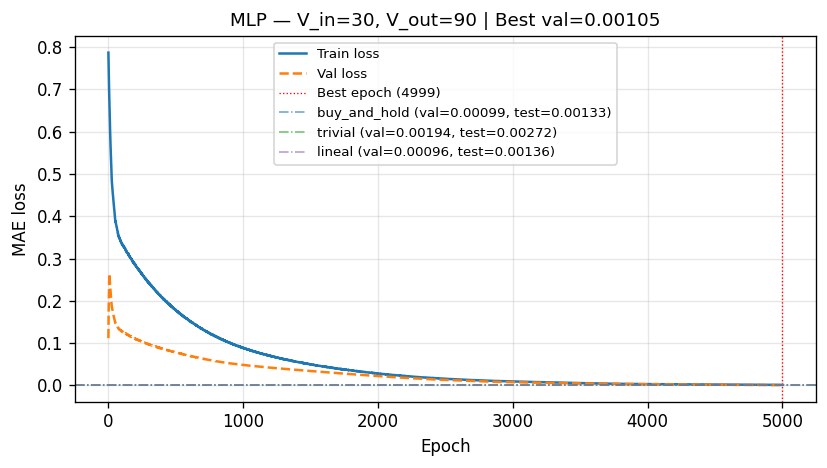

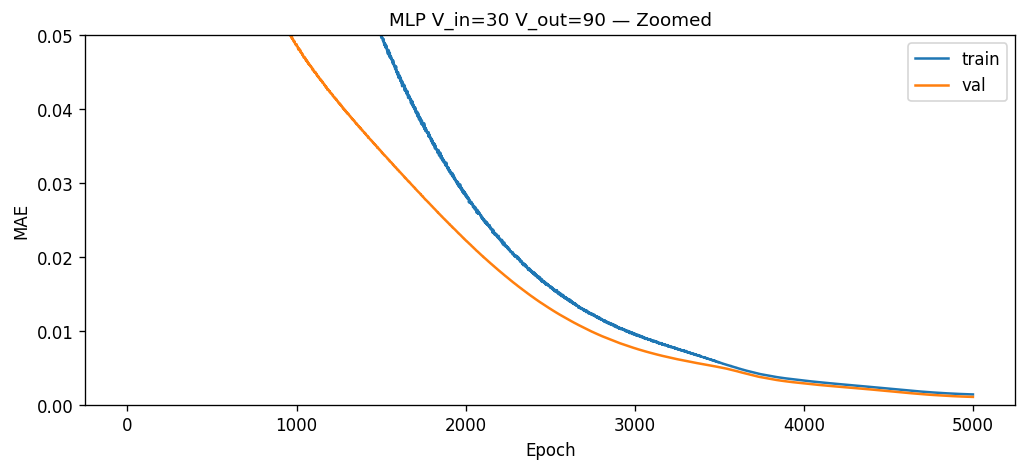


> Resultado parcial guardado: /content/drive/MyDrive/Taller4_DL_MIAX/08_results/tablas/parciales/mlp_vin30_vout90.csv

> MAE  train=0.0013  val=0.0009  test=0.0013  params=75,047


In [7]:
maes = calc_mae_all(model, X_tr, Y_tr, X_val, Y_val, X_test, Y_test)

plot_curva(history, MODELO, V_IN, V_OUT, save=True)
plt.show()

# Zoomed curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'], label='train')
ax.plot(history.history['val_loss'], label='val')
ax.set_ylim(0, 0.05)
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE')
ax.set_title(f'{MODELO} V_in={V_IN} V_out={V_OUT} — Zoomed')
ax.legend()
plt.show()

resultado = {
    'modelo':    MODELO,
    'v_in':      V_IN,
    'v_out':     V_OUT,
    'n_params':  model.count_params(),
    'mae_train': maes['train'],
    'mae_val':   maes['val'],
    'mae_test':  maes['test'],
}

ruta = guardar_resultado_parcial(resultado, MODELO, V_IN, V_OUT, verbose=True)

print(f'\n> MAE  train={maes["train"]:.4f}  val={maes["val"]:.4f}  test={maes["test"]:.4f}'
      f'  params={model.count_params():,}')